# 🛡️ Aegis — Medical Image De-identification Demo

**Before running:** place your files in Google Drive:
```
My Drive/aegis_demo/dicom/   ← .dcm files (subfolders OK)
My Drive/aegis_demo/image/   ← .jpg / .png files (subfolders OK)
```
Then run cells top to bottom.

## Cell 1 — Aegis Setup (clone repo + install)

In [ ]:
import subprocess, sys, os

if not os.path.exists('/content/aegis'):
    subprocess.run(['git', 'clone',
        'https://github.com/lakshmi-mahabaleshwara/aegis.git',
        '/content/aegis'], check=True)
    print('Repo cloned.')
else:
    subprocess.run(['git', '-C', '/content/aegis', 'pull'], check=True)
    print('Repo updated.')

os.chdir('/content/aegis')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', 'monai_aegis/', '--quiet'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fsspec', '--quiet'], check=True)

os.makedirs('staging_input/dicom',   exist_ok=True)
os.makedirs('staging_input/image',   exist_ok=True)
os.makedirs('staging_output',        exist_ok=True)
os.makedirs('staging_not_processed', exist_ok=True)

import torch
gpu = torch.cuda.is_available()
print('GPU available:', gpu)
if gpu:
    print('  Device:', torch.cuda.get_device_name(0))
print('\nSetup complete.')

Repo cloned.
GPU available: True
  Device: Tesla T4

Setup complete.


## Cell 2 — Mount Google Drive + link input folders

In [ ]:
from google.colab import drive
import os, glob, shutil, numpy as np, matplotlib.pyplot as plt, pydicom
from PIL import Image

drive.mount('/content/drive', force_remount=False)
os.chdir('/content/aegis')

# ── Change this to match your Drive folder ───────────────────────

DRIVE_DEMO_DIR = '/content/drive/MyDrive/aegis_demo'

# ─────────────────────────────────────────────────────────────────

links = [
    (os.path.join(DRIVE_DEMO_DIR, 'dicom'), 'staging_input/dicom'),
    (os.path.join(DRIVE_DEMO_DIR, 'image'), 'staging_input/image'),
]
for src, dst in links:
    if not os.path.isdir(src):
        print('❌  Not found in Drive: {}'.format(src))
        continue
    if os.path.islink(dst):
        os.unlink(dst)
    elif os.path.isdir(dst):
        shutil.rmtree(dst)
    os.symlink(src, dst)
    count = sum(1 for f in os.listdir(dst) if not f.startswith('.'))
    print('✅  {} → {}  ({} items)'.format(dst, src, count))

print('\nDrive linked.')

Mounted at /content/drive
✅  staging_input/dicom → /content/drive/MyDrive/aegis_demo/dicom  (3 items)
✅  staging_input/image → /content/drive/MyDrive/aegis_demo/image  (6 items)

Drive linked.


## Cell 3 — Load configuration (with overlay)

In [ ]:
import torch, os
from monai_aegis.config.config_loader import load_config

CONFIG_PATH = 'monai_aegis/config/config.yaml'

# ── Write single combined overlay ────────────────────────────────
GPU_AVAILABLE = torch.cuda.is_available()
OVERLAY_PATH  = 'monai_aegis/config/demo_overlay.yaml'

with open(OVERLAY_PATH, 'w') as f:
    f.write("""# Aegis demo overlay — auto-generated, do not edit manually
paths:
  input_dir: {input_dir}
  output_dir: /content/aegis/staging_output
  not_processed_dir: /content/aegis/staging_not_processed

ocr:
  gpu_usage: {gpu}

ner:
  device: {device}
""".format(
        input_dir = DRIVE_DEMO_DIR,
        gpu       = 'true' if GPU_AVAILABLE else 'false',
        device    = 'cuda' if GPU_AVAILABLE else 'cpu',
    ))

print('Overlay written to:', OVERLAY_PATH)
print('---')
with open(OVERLAY_PATH) as f:
    print(f.read())
print('GPU detected:', GPU_AVAILABLE)

# ── Set env var and load once ─────────────────────────────────────

os.environ['AEGIS_CONFIG_OVERRIDE'] = os.path.abspath(OVERLAY_PATH)

config = load_config(CONFIG_PATH)

INPUT_DIR  = 'staging_input'
OUTPUT_DIR = 'staging_output'

print('=== Active config after overlay ===')
print('  input_dir :', config['paths']['input_dir'])
print('  output_dir:', config['paths']['output_dir'])
print('  gpu_usage :', config['ocr']['gpu_usage'])
print('  ner device:', config['ner']['device'])

print('\n=== NER Settings ===')
ner = config.get('ner', {})
print('  enabled : {}'.format(ner.get('enabled')))
print('  model   : {}'.format(ner.get('model_name')))
labels = ner.get('phi_labels', [])
print('  PHI labels ({}) : {}...'.format(len(labels), labels[:5]))

print('\n=== PII Mapping — PS3.15 Basic Profile ===')
for tag, action in config.get('pii_mapping', {}).items():
    print('  {} : {}'.format(tag, action))

print('\n✅  Config loaded with overlay applied')

Overlay written to: monai_aegis/config/demo_overlay.yaml
---
# Aegis demo overlay — auto-generated, do not edit manually
paths:
  input_dir: /content/drive/MyDrive/aegis_demo
  output_dir: /content/aegis/staging_output
  not_processed_dir: /content/aegis/staging_not_processed

ocr:
  gpu_usage: true

ner:
  device: cuda

GPU detected: True
=== Active config after overlay ===
  input_dir : /content/drive/MyDrive/aegis_demo
  output_dir: /content/aegis/staging_output
  gpu_usage : True
  ner device: cuda

=== NER Settings ===
  enabled : True
  model   : StanfordAIMI/stanford-deidentifier-base
  PHI labels (22) : ['PATIENT', 'DOCTOR', 'USERNAME', 'IDNUM', 'MEDICALRECORD']...

=== PII Mapping — PS3.15 Basic Profile ===
  (0010,0010) : DUMMY
  (0010,0020) : DUMMY
  (0010,0030) : REMOVE
  (0008,0020) : ZERO
  (0008,0050) : REMOVE
  (0008,0090) : DUMMY
  (0008,0080) : REMOVE
  (0010,0040) : REMOVE
  (0010,1010) : REMOVE
  (0010,1020) : REMOVE
  (0010,1030) : REMOVE
  (0008,0081) : REMOVE
  (

---
## -------------- PART A: DICOM -------------------

## Cell 4 — Inspect DICOM input files

In [ ]:
DICOM_INPUT_DIR = os.path.join(DRIVE_DEMO_DIR, 'dicom')

dcm_files = []
for root, _, fnames in os.walk(DICOM_INPUT_DIR):
    for f in sorted(fnames):
        if f.startswith('.'):
            continue
        fp  = os.path.join(root, f)
        rel = os.path.relpath(fp, DICOM_INPUT_DIR)
        ext = os.path.splitext(f)[1].lower()
        if ext == '.dcm':
            dcm_files.append(rel)
        elif ext == '':
            try:
                with open(fp, 'rb') as fh:
                    fh.seek(128)
                    if fh.read(4) == b'DICM':
                        dcm_files.append(rel)
            except Exception:
                pass

print('Found {} DICOM file(s) in {}\n'.format(len(dcm_files), DICOM_INPUT_DIR))
for f in dcm_files:
    fp = os.path.join(DICOM_INPUT_DIR, f)
    print('  {:7.1f} KB  {}'.format(os.path.getsize(fp)/1024, f))

if not dcm_files:
    print('No DICOM files found. Add .dcm files to Drive and re-run.')

Found 48 DICOM file(s) in /content/drive/MyDrive/aegis_demo/dicom

    497.6 KB  U0000001.dcm
    497.6 KB  leg/18444546/1/U0000001.dcm
    497.6 KB  leg/18444546/1/U0000002
    497.6 KB  leg/18444546/1/U0000003
    497.6 KB  leg/18444546/1/U0000004
    497.6 KB  leg/18444546/1/U0000005
    497.6 KB  leg/18444546/1/U0000006
    497.6 KB  leg/18444546/1/U0000007
    497.6 KB  leg/18444546/1/U0000008
    497.6 KB  leg/18444546/1/U0000009
    497.6 KB  leg/18444546/1/U0000010
    497.6 KB  leg/18444546/1/U0000011
    497.6 KB  leg/18444546/1/U0000012
    497.6 KB  leg/18444546/1/U0000013
    538.6 KB  leg/18444546/2/U0000001
    538.6 KB  leg/18444546/2/U0000002
    538.6 KB  leg/18444546/2/U0000003
    538.6 KB  leg/18444546/2/U0000004
    538.6 KB  leg/18444546/2/U0000005
    538.6 KB  leg/18444546/2/U0000006
    538.6 KB  leg/18444546/2/U0000007
    538.6 KB  leg/18444546/2/U0000008
    538.6 KB  leg/18444546/2/U0000009
    538.6 KB  leg/18444546/2/U0000010
    538.6 KB  leg/18444546/2

## Cell 5 — Preview BEFORE (PHI visible)

Using: U0000001.dcm


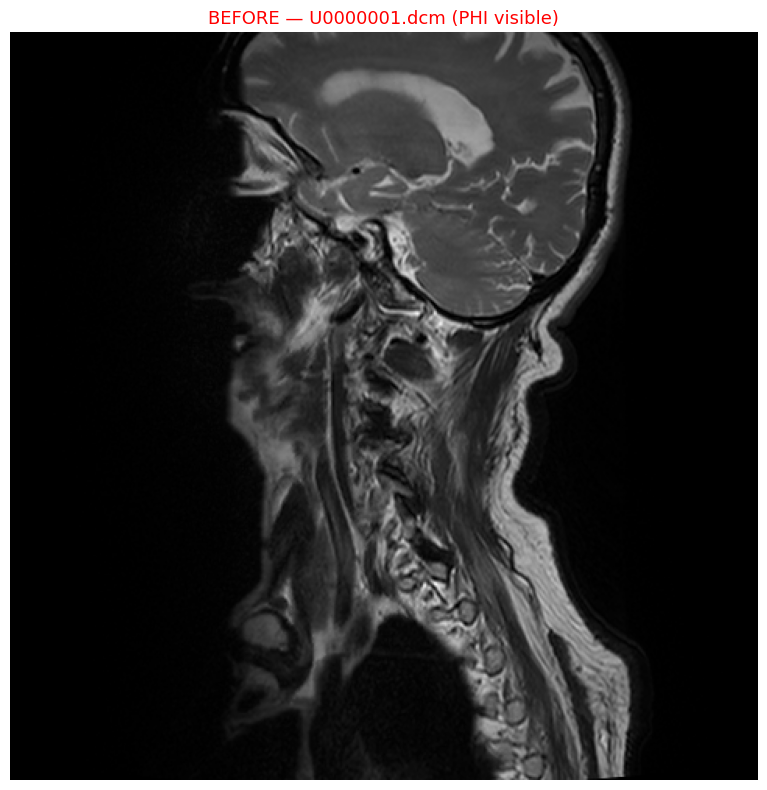


Raw DICOM tags before de-identification:
  PatientName         : MAHABALESHWARA
  PatientID           : BIL4858364
  PatientBirthDate    : 
  StudyDate           : 20241022
  InstitutionName     : TENET DIAGNOSTICS
  Modality            : MR


In [ ]:
if not dcm_files:
    raise RuntimeError('No DICOM files found. Run Cell 4 first.')

DCM_SAMPLE      = dcm_files[0]
dcm_sample_path = os.path.join(DICOM_INPUT_DIR, DCM_SAMPLE)
print('Using:', DCM_SAMPLE)

ds_before = pydicom.dcmread(dcm_sample_path)
arr = ds_before.pixel_array.astype(float)
arr = ((arr - arr.min()) / (arr.max() - arr.min() + 1e-5) * 255).astype('uint8')

plt.figure(figsize=(10, 8))
plt.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
plt.title('BEFORE — {} (PHI visible)'.format(DCM_SAMPLE), fontsize=13, color='red')
plt.axis('off'); plt.tight_layout(); plt.show()

print('\nRaw DICOM tags before de-identification:')
for field in ['PatientName','PatientID','PatientBirthDate','StudyDate','InstitutionName','Modality']:
    print('  {:<20}: {}'.format(field, getattr(ds_before, field, 'N/A')))

## Cell 6 — Build and run DICOM pipeline

In [ ]:
print('Running dicom_runner...\n')
from monai_aegis import dicom_runner

# Verify what the runner will use
from monai_aegis.config.config_loader import load_config as _lc
run_cfg = _lc(CONFIG_PATH)
print('input_dir  :', run_cfg['paths']['input_dir'])
print('output_dir :', run_cfg['paths']['output_dir'])
reachable = sum(
    1 for root, _, fnames in os.walk(run_cfg['paths']['input_dir'])
    for f in fnames if not f.startswith('.')
)
print('Files reachable:', reachable, '\n')

dicom_runner.run_series(config_path=os.path.abspath(CONFIG_PATH))
print('\n✅  DICOM runner complete')

Running dicom_runner...

input_dir  : /content/drive/MyDrive/aegis_demo
output_dir : /content/aegis/staging_output
Files reachable: 70 



Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/pydicom/dataset.py:3429: UserWarning: The ValueError exception 'I/O operation on closed file' occurred trying to deepcopy the buffer-like the dataset was read from, the 'buffer' attribute will be set to 'None' in the copied object
  warn_and_log(
/usr/local/lib/python3.12/dist-packages/pydicom/valuerep.py:440: UserWarning: The value length (22) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)



✅  DICOM runner complete


## Cell 7 — Redaction stats + DICOM Metadata Before / After

In [ ]:
import glob

output_dcm_files = sorted(glob.glob('/content/aegis/staging_output/dicom/**/*.dcm', recursive=True))
quarantined      = sorted(glob.glob('/content/aegis/staging_not_processed/**/*.dcm', recursive=True))

print('=== Pipeline Run Summary ===')
print('  Output files     :', len(output_dcm_files))
print('  Quarantined files:', len(quarantined))

if output_dcm_files:
    ts_folders = sorted(set(os.path.dirname(f) for f in output_dcm_files))
    print('  Timestamp folder(s):')
    for folder in ts_folders:
        print('    {}'.format(folder))

if quarantined:
    print('\n⚠️  Quarantined (low-confidence / errors):')
    for f in quarantined:
        print('    {}'.format(f))
else:
    print('\n✅  No files quarantined')

SCRUBBED_DCM_PATH = output_dcm_files[0] if output_dcm_files else None

if not SCRUBBED_DCM_PATH:
    print('\nNo output DICOM found — check runner output above.')
else:
    ds_after = pydicom.dcmread(SCRUBBED_DCM_PATH)
    pii_tags = [
        ('(0010,0010)', 'PatientName'),
        ('(0010,0020)', 'PatientID'),
        ('(0010,0030)', 'PatientBirthDate'),
        ('(0008,0020)', 'StudyDate'),
        ('(0008,0050)', 'AccessionNumber'),
        ('(0008,0090)', 'ReferringPhysicianName'),
        ('(0008,0080)', 'InstitutionName'),
        ('(0008,0021)', 'SeriesDate'),
        ('(0008,0023)', 'ContentDate'),
    ]
    def _tag_val(ds, tag_str):
        parts = tag_str.strip('()').split(',')
        tag = pydicom.tag.Tag(int(parts[0].strip(), 16), int(parts[1].strip(), 16))
        return str(ds[tag].value) if tag in ds else '<REMOVED>'

    print('\n=== DICOM Metadata: Before vs After ===')
    print('{:<18} {:<26} {:<32} {}'.format('Tag', 'Field', 'BEFORE', 'AFTER'))
    print('-' * 100)
    for tag, name in pii_tags:
        before = _tag_val(ds_before, tag)
        after  = _tag_val(ds_after,  tag)
        marker = '🔴' if before != after else '⚪'
        print('{} {:<16} {:<26} {:<32} {}'.format(marker, tag, name, before[:30], after))

=== Pipeline Run Summary ===
  Output files     : 8
  Quarantined files: 0
  Timestamp folder(s):
    /content/aegis/staging_output/dicom/2026-04-06_14-53
    /content/aegis/staging_output/dicom/2026-04-06_14-53/TOKEN_39175a07d17e9721
    /content/aegis/staging_output/dicom/2026-04-06_14-53/TOKEN_efebd92fa5dfdf16/18444546/1

✅  No files quarantined

=== DICOM Metadata: Before vs After ===
Tag                Field                      BEFORE                           AFTER
----------------------------------------------------------------------------------------------------
🔴 (0010,0010)      PatientName                MAHABALESHWARA                   TOKEN_6410e20fb9deaae9
🔴 (0010,0020)      PatientID                  BIL4858364                       TOKEN_20c5d76e41429916
🔴 (0010,0030)      PatientBirthDate                                            <REMOVED>
🔴 (0008,0020)      StudyDate                  20241022                         
🔴 (0008,0050)      AccessionNumber            235

## Cell 8 — US Region Masking

In [ ]:
# Load the sample DICOM fresh to inspect US regions
ds = pydicom.dcmread(dcm_sample_path)
modality = getattr(ds, 'Modality', 'N/A')
print('Modality:', modality)

if (0x0018, 0x6011) in ds:
    regions = ds[0x0018, 0x6011].value
    print('SequenceOfUltrasoundRegions — {} region(s) found:'.format(len(regions)))
    for i, r in enumerate(regions):
        x0  = getattr(r, 'RegionLocationMinX0', 'N/A')
        y0  = getattr(r, 'RegionLocationMinY0', 'N/A')
        x1  = getattr(r, 'RegionLocationMaxX1', 'N/A')
        y1  = getattr(r, 'RegionLocationMaxY1', 'N/A')
        fmt = getattr(r, 'RegionSpatialFormat', 'N/A')
        print('  Region {}: ({},{}) → ({},{})  spatial_format={}'.format(i,x0,y0,x1,y1,fmt))

    # Build and visualise the mask directly
    from monai_aegis.transforms.us_regions import build_us_phi_mask
    orig = ds.pixel_array
    H, W = orig.shape[:2]
    mask = build_us_phi_mask(ds, H, W)
    if mask is not None:
        phi_pct = int(100 * mask.sum() / mask.size)
        print('\nPHI zone (OCR scanned)    : {}% of frame'.format(phi_pct))
        print('Diagnostic fan (protected): {}% of frame'.format(100 - phi_pct))
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(orig, cmap='gray' if orig.ndim == 2 else None)
        axes[0].set_title('Original frame'); axes[0].axis('off')
        axes[1].imshow(mask, cmap='hot')
        axes[1].set_title('US PHI mask  (bright = OCR zone)'); axes[1].axis('off')
        plt.suptitle('SequenceOfUltrasoundRegions — Fan geometry', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()
else:
    print('No (0018,6011) tag — not a tagged US file.')
    print('RedactByUSRegionsd was a no-op; full-frame OCR ran on this file.')

Modality: MR
No (0018,6011) tag — not a tagged US file.
RedactByUSRegionsd was a no-op; full-frame OCR ran on this file.


## Cell 9 — BEFORE / AFTER side-by-side

Before file : /content/drive/MyDrive/aegis_demo/dicom/U0000001.dcm
After file  : /content/aegis/staging_output/dicom/2026-04-06_14-53/TOKEN_efebd92fa5dfdf16/18444546/1/U0000001.dcm


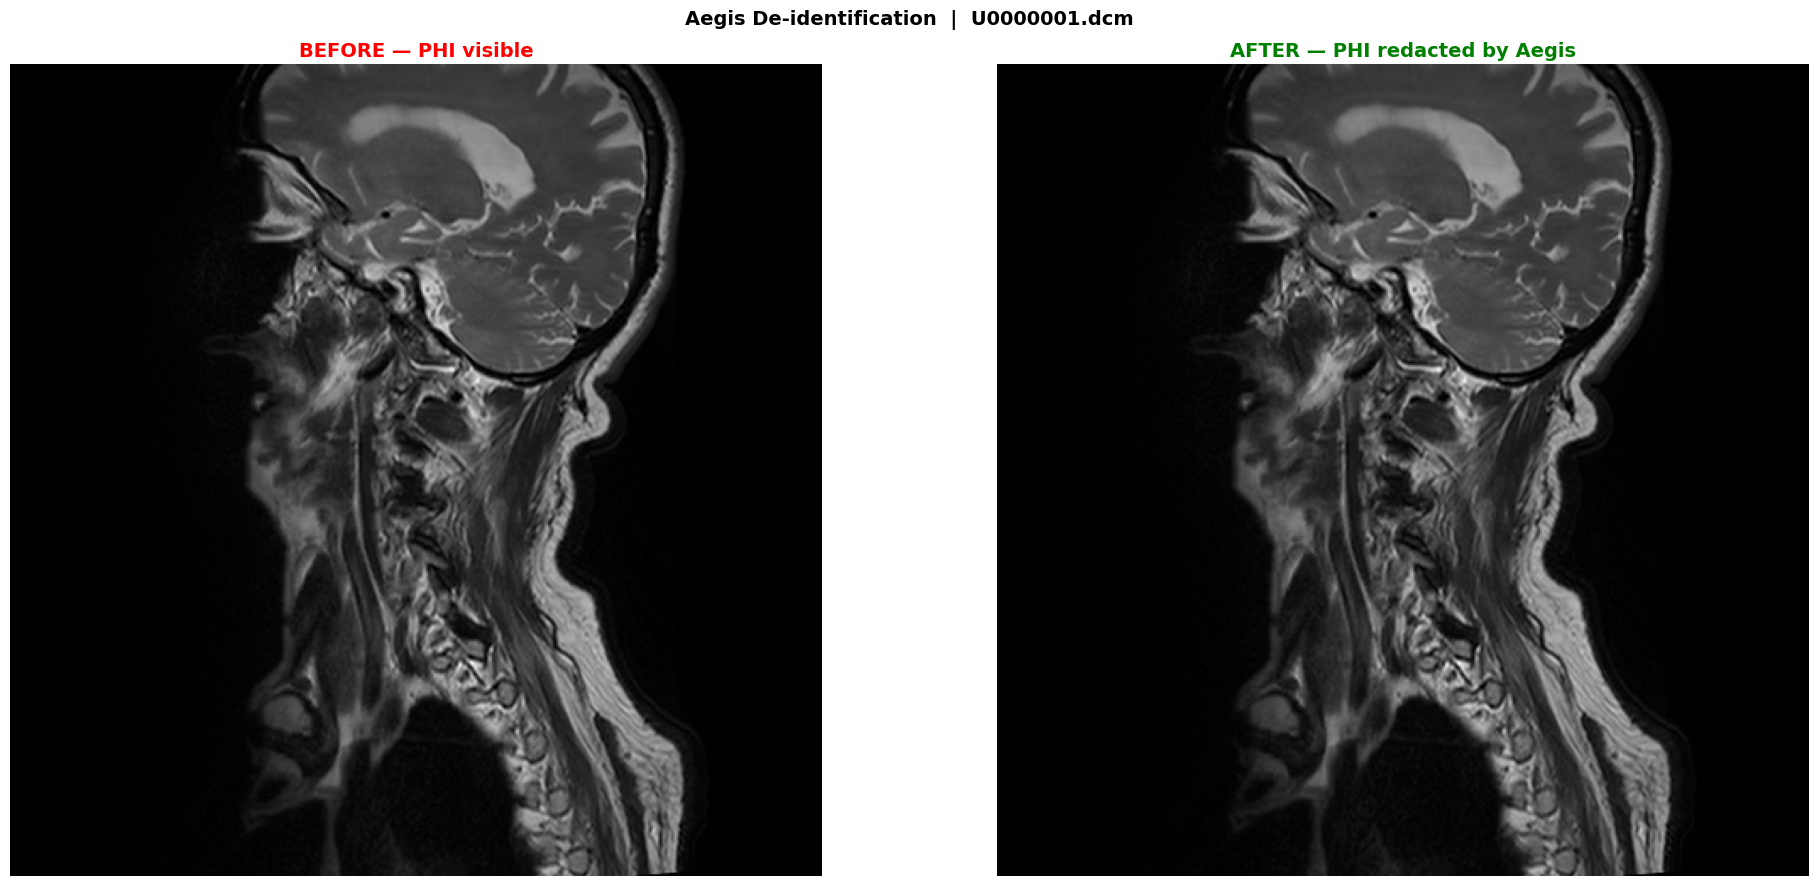


=== DICOM Metadata: Before vs After ===
Tag                Field                      BEFORE                           AFTER
----------------------------------------------------------------------------------------------------
🔴 (0010,0010)      PatientName                MAHABALESHWARA                   TOKEN_cd7cf9cf40204e63
🔴 (0010,0020)      PatientID                  BIL4858364                       TOKEN_a56861331abc06ff
🔴 (0010,0030)      PatientBirthDate                                            <REMOVED>
🔴 (0008,0020)      StudyDate                  20241022                         
🔴 (0008,0050)      AccessionNumber            23564863                         <REMOVED>
🔴 (0008,0090)      ReferringPhysicianName     DR.PRAVEN KUMAR RAI G            TOKEN_02299d976d7afb87
🔴 (0008,0080)      InstitutionName            TENET DIAGNOSTICS                <REMOVED>
🔴 (0008,0021)      SeriesDate                 20241022                         
🔴 (0008,0023)      ContentDate          

In [ ]:
import glob, pydicom

# ── Find the output file that matches DCM_SAMPLE ─────────────────
# The runner preserves the original filename, so we match by filename
dcm_basename = os.path.basename(DCM_SAMPLE)
output_dcm_files = sorted(glob.glob(
    '/content/aegis/staging_output/dicom/**/*',
    recursive=True
))

# Try to find a match by filename first
SCRUBBED_DCM_PATH = None
for f in output_dcm_files:
    if os.path.basename(f) == dcm_basename:
        SCRUBBED_DCM_PATH = f
        break

# Fall back to first output file if no name match
if not SCRUBBED_DCM_PATH and output_dcm_files:
    SCRUBBED_DCM_PATH = output_dcm_files[0]
    print('⚠️  Exact filename match not found — using first output file')

print('Before file :', dcm_sample_path)
print('After file  :', SCRUBBED_DCM_PATH)

if not SCRUBBED_DCM_PATH:
    print('\nNo output DICOM found. Check Cell 6.')
else:
    ds_after = pydicom.dcmread(SCRUBBED_DCM_PATH)

    # ── Visual before / after ─────────────────────────────────────
    def to_display(arr):
        arr = arr.astype(float)
        return ((arr - arr.min()) / (arr.max() - arr.min() + 1e-5) * 255).astype('uint8')

    orig_display  = to_display(ds_before.pixel_array)
    after_display = to_display(ds_after.pixel_array)

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    axes[0].imshow(orig_display,  cmap='gray' if orig_display.ndim  == 2 else None)
    axes[0].set_title('BEFORE — PHI visible',         fontsize=14, color='red',   fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(after_display, cmap='gray' if after_display.ndim == 2 else None)
    axes[1].set_title('AFTER — PHI redacted by Aegis', fontsize=14, color='green', fontweight='bold')
    axes[1].axis('off')
    plt.suptitle('Aegis De-identification  |  {}'.format(DCM_SAMPLE),
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── DICOM Metadata: Before vs After ──────────────────────────
    pii_tags = [
        ('(0010,0010)', 'PatientName'),
        ('(0010,0020)', 'PatientID'),
        ('(0010,0030)', 'PatientBirthDate'),
        ('(0008,0020)', 'StudyDate'),
        ('(0008,0050)', 'AccessionNumber'),
        ('(0008,0090)', 'ReferringPhysicianName'),
        ('(0008,0080)', 'InstitutionName'),
        ('(0008,0021)', 'SeriesDate'),
        ('(0008,0023)', 'ContentDate'),
    ]

    def _tag_val(ds, tag_str):
        parts = tag_str.strip('()').split(',')
        tag = pydicom.tag.Tag(int(parts[0].strip(), 16), int(parts[1].strip(), 16))
        return str(ds[tag].value) if tag in ds else '<REMOVED>'

    print('\n=== DICOM Metadata: Before vs After ===')
    print('{:<18} {:<26} {:<32} {}'.format('Tag', 'Field', 'BEFORE', 'AFTER'))
    print('-' * 100)
    changed, unchanged = 0, 0
    for tag, name in pii_tags:
        before = _tag_val(ds_before, tag)
        after  = _tag_val(ds_after,  tag)
        if before != after:
            marker = '🔴'
            changed += 1
        else:
            marker = '⚪'
            unchanged += 1
        print('{} {:<16} {:<26} {:<32} {}'.format(
            marker, tag, name, before[:30], after))

    print('\n  🔴 Changed  : {}'.format(changed))
    print('  ⚪ Unchanged: {}'.format(unchanged))

---
## ---------- PART B: JPEG / PNG IMAGE ---------------

## Cell 11 — Inspect image input files

In [ ]:
IMAGE_INPUT_DIR = os.path.join(DRIVE_DEMO_DIR, 'image')

img_files = []
for root, _, fnames in os.walk(IMAGE_INPUT_DIR):
    for f in sorted(fnames):
        if f.startswith('.'):
            continue
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            fp  = os.path.join(root, f)
            rel = os.path.relpath(fp, IMAGE_INPUT_DIR)
            img_files.append(rel)

print('Found {} image file(s) in {}\n'.format(len(img_files), IMAGE_INPUT_DIR))
for f in img_files:
    fp = os.path.join(IMAGE_INPUT_DIR, f)
    print('  {:7.1f} KB  {}'.format(os.path.getsize(fp)/1024, f))

if not img_files:
    print('No image files found. Add .jpg/.png files to Drive and re-run.')

Found 22 image file(s) in /content/drive/MyDrive/aegis_demo/image

    248.3 KB  202601170918250004ABD.JPG
    162.8 KB  invalid_dimension_data.png
    248.3 KB  20260117-091825-6AAA/ABD20260117091825/202601170918250004ABD.JPG
    278.7 KB  20260117-091825-6AAA/ABD20260117091825/202601170922370005ABD.JPG
    274.5 KB  20260117-091825-6AAA/ABD20260117091825/202601170926060006ABD.JPG
    245.9 KB  20260117-091825-6AAA/ABD20260117091825/202601170926420007ABD.JPG
    275.7 KB  20260117-091825-6AAA/ABD20260117091825/202601170927040008ABD.JPG
    230.3 KB  20260117-091825-6AAA/ABD20260117091825/202601170929370009ABD.JPG
    278.7 KB  us-without-sub-folder/202601170922370005ABD.JPG
    274.5 KB  us-without-sub-folder/202601170926060006ABD.JPG
    245.9 KB  us-without-sub-folder/202601170926420007ABD.JPG
    275.7 KB  us-without-sub-folder/202601170927040008ABD.JPG
    230.3 KB  us-without-sub-folder/202601170929370009ABD.JPG
    213.6 KB  20260124-153417-6AAA/ABD20260124153417/202601241534170

## Cell 12 — Preview BEFORE image (PHI visible)

Using: 202601170918250004ABD.JPG


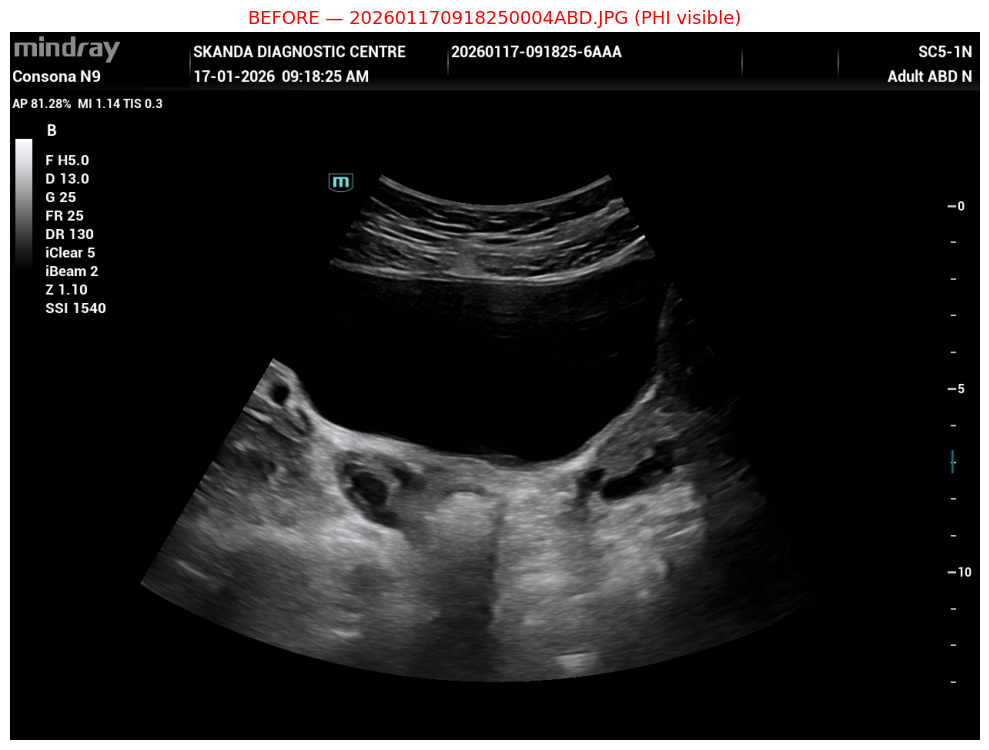

In [ ]:
if not img_files:
    raise RuntimeError('No image files found. Run Cell 11 first.')

IMG_SAMPLE      = img_files[0]
img_sample_path = os.path.join(IMAGE_INPUT_DIR, IMG_SAMPLE)
print('Using:', IMG_SAMPLE)

orig_img = np.array(Image.open(img_sample_path).convert('RGB'))
plt.figure(figsize=(10, 8))
plt.imshow(orig_img)
plt.title('BEFORE — {} (PHI visible)'.format(IMG_SAMPLE), fontsize=13, color='red')
plt.axis('off'); plt.tight_layout(); plt.show()

## Cell 13 — Build and run image pipeline

In [ ]:
print('Running image_runner...\n')
from monai_aegis import image_runner

image_runner.run_series(config_path=os.path.abspath(CONFIG_PATH))
print('\n✅  Image runner complete')

Running image_runner...



/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: StanfordAIMI/stanford-deidentifier-base
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
ERROR:monai_aegis.image_runner:Error in transform pipeline: ['/content/drive/MyDrive/aegis_demo/image/improper_dataset/2.png', '/content/drive/MyDrive/aegis_demo/image/improper_dataset/3.png']
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/monai/transforms/transform.py", line 150, in apply_transform
    retur


✅  Image runner complete


## Cell 14 — Image redaction stats + Before / After

=== Image Pipeline Run Summary ===
  Output files     : 19
  Quarantined files: 3
  Timestamp folder(s):
    /content/aegis/staging_output/image/2026-04-06_15-01
    /content/aegis/staging_output/image/2026-04-06_15-01/TOKEN_32f35f29a9472f7d
    /content/aegis/staging_output/image/2026-04-06_15-01/TOKEN_e7bd88746726482f/ABD20260117091825
    /content/aegis/staging_output/image/2026-04-06_15-01/TOKEN_f2371b1f343ed449/ABD20260124153417

⚠️  Quarantined (low-confidence / invalid dimensions):
    /content/aegis/staging_not_processed/improper_dataset/2.png
    /content/aegis/staging_not_processed/improper_dataset/3.png
    /content/aegis/staging_not_processed/invalid_dimension_data.png

⚠️  Exact filename match not found — using first output file

=== Pixel-level Redaction Stats — 202601170918250004ABD.JPG ===
  Image size       : 1260×920
  Total pixels     : 1,159,200
  Redacted pixels  : 8,404  (0.72%)
  Preserved pixels : 1,150,796  (99.28%)

  ✅  PHI regions zeroed, diagnostic content 

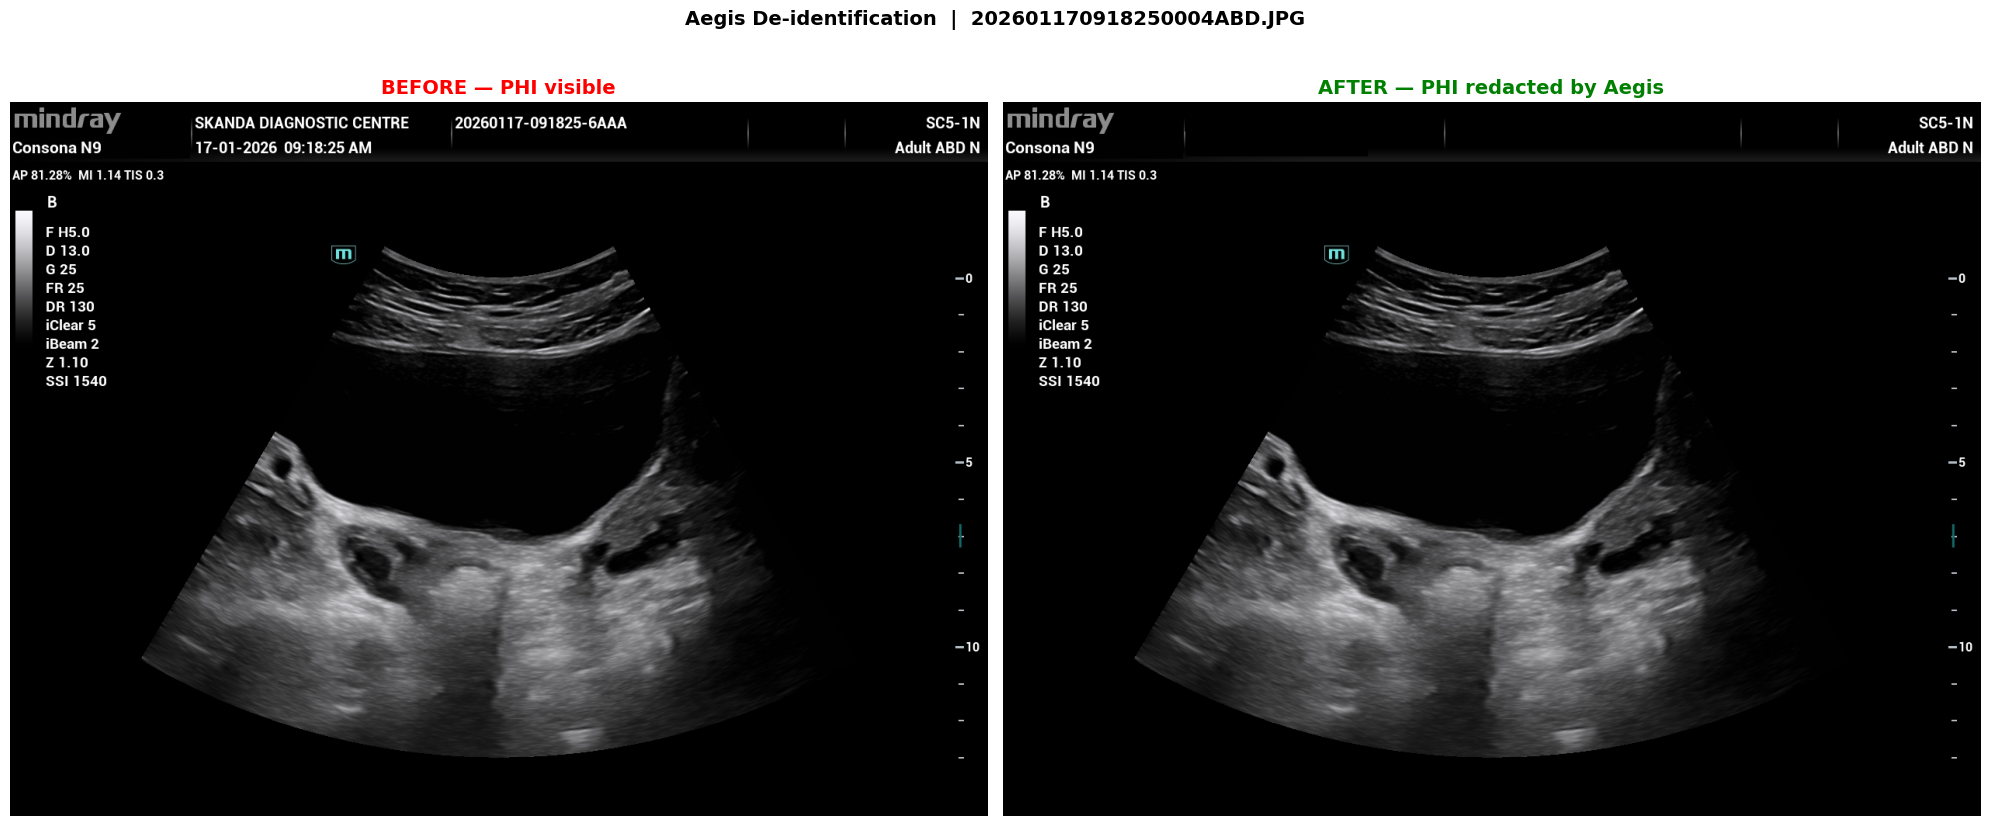

In [ ]:
import glob, pydicom
from PIL import Image

# ── Find output files ─────────────────────────────────────────────
output_img_files = sorted(
    glob.glob('/content/aegis/staging_output/image/**/*.jpg',  recursive=True) +
    glob.glob('/content/aegis/staging_output/image/**/*.jpeg', recursive=True) +
    glob.glob('/content/aegis/staging_output/image/**/*.png',  recursive=True)
)
quarantined_img = sorted(
    glob.glob('/content/aegis/staging_not_processed/**/*.jpg',  recursive=True) +
    glob.glob('/content/aegis/staging_not_processed/**/*.jpeg', recursive=True) +
    glob.glob('/content/aegis/staging_not_processed/**/*.png',  recursive=True)
)

# ── Run summary ───────────────────────────────────────────────────
print('=== Image Pipeline Run Summary ===')
print('  Output files     :', len(output_img_files))
print('  Quarantined files:', len(quarantined_img))

if output_img_files:
    ts_folders = sorted(set(os.path.dirname(f) for f in output_img_files))
    print('  Timestamp folder(s):')
    for folder in ts_folders:
        print('    {}'.format(folder))

if quarantined_img:
    print('\n⚠️  Quarantined (low-confidence / invalid dimensions):')
    for f in quarantined_img:
        print('    {}'.format(f))
else:
    print('\n✅  No files quarantined')

# ── Per-file stats by comparing before vs after pixel-level ──────
img_basename = os.path.basename(IMG_SAMPLE)
SCRUBBED_IMG_PATH = None
for f in output_img_files:
    if os.path.basename(f) == img_basename:
        SCRUBBED_IMG_PATH = f
        break
if not SCRUBBED_IMG_PATH and output_img_files:
    SCRUBBED_IMG_PATH = output_img_files[0]
    print('\n⚠️  Exact filename match not found — using first output file')

if SCRUBBED_IMG_PATH:
    before_arr = np.array(Image.open(img_sample_path).convert('RGB'))
    after_arr  = np.array(Image.open(SCRUBBED_IMG_PATH).convert('RGB'))

    # Pixels that changed = redacted regions
    diff          = np.any(before_arr != after_arr, axis=2)
    redacted_px   = int(diff.sum())
    total_px      = diff.size
    redacted_pct  = round(100 * redacted_px / total_px, 2)
    unchanged_pct = round(100 - redacted_pct, 2)

    print('\n=== Pixel-level Redaction Stats — {} ==='.format(IMG_SAMPLE))
    print('  Image size       : {}×{}'.format(before_arr.shape[1], before_arr.shape[0]))
    print('  Total pixels     : {:,}'.format(total_px))
    print('  Redacted pixels  : {:,}  ({}%)'.format(redacted_px, redacted_pct))
    print('  Preserved pixels : {:,}  ({}%)'.format(total_px - redacted_px, unchanged_pct))

    if redacted_px == 0:
        print('\n  ℹ️  No pixels changed — either no PHI detected or file unchanged')
    else:
        print('\n  ✅  PHI regions zeroed, diagnostic content preserved')

    # ── Before / After visual ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    axes[0].imshow(before_arr)
    axes[0].set_title('BEFORE — PHI visible',
                      fontsize=14, color='red', fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(after_arr)
    axes[1].set_title('AFTER — PHI redacted by Aegis',
                      fontsize=14, color='green', fontweight='bold')
    axes[1].axis('off')
    plt.suptitle('Aegis De-identification  |  {}'.format(IMG_SAMPLE),
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('\nNo output image found — check runner output above.')

## Thank You